In [15]:
import pandas as pd
df=pd.read_csv("mock_kaggle.csv")

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
df.head()

,data,venda,estoque,preco
0,2014-01-01,0,4972,1.29
1,2014-01-02,70,4902,1.29
2,2014-01-03,59,4843,1.29
3,2014-01-04,93,4750,1.29
4,2014-01-05,96,4654,1.29


In [18]:
df.tail()

,data,venda,estoque,preco
932,2016-07-27,98,3179,2.39
933,2016-07-28,108,3071,2.39
934,2016-07-29,128,4095,2.39
935,2016-07-30,270,3825,2.39
936,2016-07-31,183,3642,2.39


In [19]:
df.shape

(937, 4)

In [20]:
df.columns

Index(['data', 'venda', 'estoque', 'preco'], dtype='object')

In [21]:
df.isnull().sum()

,0
data,0
venda,0
estoque,0
preco,0


In [22]:
df.describe()

,venda,estoque,preco
count,937.000000,937.000000,937.000000
mean,90.533618,1608.258271,1.592572
std,80.682089,1356.691877,0.529502
min,0.000000,0.000000,0.000000
25%,33.000000,794.000000,1.290000
50%,76.000000,1348.000000,1.390000
75%,127.000000,1964.000000,1.890000
max,542.000000,7228.000000,2.980000


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of            data  venda  estoque  preco
0    2014-01-01      0     4972   1.29
1    2014-01-02     70     4902   1.29
2    2014-01-03     59     4843   1.29
3    2014-01-04     93     4750   1.29
4    2014-01-05     96     4654   1.29
..          ...    ...      ...    ...
932  2016-07-27     98     3179   2.39
933  2016-07-28    108     3071   2.39
934  2016-07-29    128     4095   2.39
935  2016-07-30    270     3825   2.39
936  2016-07-31    183     3642   2.39

[937 rows x 4 columns]>

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     937 non-null    object 
 1   venda    937 non-null    int64  
 2   estoque  937 non-null    int64  
 3   preco    937 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 29.4+ KB


In [28]:
df[df["venda"] > 100]

,data,venda,estoque,preco
5,2014-01-06,145,4509,1.29
6,2014-01-07,179,4329,1.29
7,2014-01-08,321,4104,1.29
8,2014-01-09,125,4459,1.09
10,2014-01-11,188,5239,1.09
...,...,...,...,...
929,2016-07-24,130,1420,2.39
933,2016-07-28,108,3071,2.39
934,2016-07-29,128,4095,2.39
935,2016-07-30,270,3825,2.39


In [29]:
df[df["preco"] > 2]

,data,venda,estoque,preco
204,2014-07-29,26,1207,2.98
401,2015-02-12,50,1116,2.84
402,2015-02-13,20,1096,2.89
403,2015-02-14,77,1019,2.89
404,2015-02-15,33,986,2.89
...,...,...,...,...
932,2016-07-27,98,3179,2.39
933,2016-07-28,108,3071,2.39
934,2016-07-29,128,4095,2.39
935,2016-07-30,270,3825,2.39


In [30]:
df.sort_values("estoque")

,data,venda,estoque,preco
616,2015-09-15,77,0,0.93
617,2015-09-16,174,0,0.97
618,2015-09-17,69,0,1.68
615,2015-09-14,69,0,0.97
306,2014-11-09,239,0,1.49
...,...,...,...,...
43,2014-02-16,87,6875,1.09
42,2014-02-15,116,6962,1.09
41,2014-02-14,107,7078,1.09
40,2014-02-13,43,7185,1.09


In [31]:
df["preco"].mean()

np.float64(1.5925720384204909)

In [33]:
df["preco"].median()

1.39

In [34]:
df["preco"].mode()

,preco
0,1.29


In [35]:
df["preco"].var()

0.2803719031916736

In [36]:
df["preco"].std()

0.5295015610852093

In [37]:
correlation = df.corr(numeric_only=True)

print(correlation)

            venda   estoque     preco
venda    1.000000  0.153659  0.094779
estoque  0.153659  1.000000 -0.032604
preco    0.094779 -0.032604  1.000000


In [38]:
Q1 = df["venda"].quantile(0.25)
Q3 = df["venda"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["venda"] < lower) | (df["venda"] > upper)]

print(outliers)

           data  venda  estoque  preco
7    2014-01-08    321     4104   1.29
28   2014-01-30    272     2723   0.99
30   2014-02-01    369     2145   0.99
152  2014-06-07    331     2446   1.19
153  2014-06-08    271     2175   1.19
180  2014-07-05    335     1119   1.29
181  2014-07-06    299      820   1.29
229  2014-08-23    338     1356   1.19
305  2014-11-08    542      175   1.49
431  2015-03-14    300     1575   1.29
438  2015-03-21    381      475   1.29
634  2015-10-03    391      976   1.48
711  2015-12-19    295     2533   1.39
712  2015-12-20    311     2222   1.39
714  2015-12-22    377     1594   1.39
715  2015-12-23    410     1184   1.39
753  2016-01-30    293     1617   1.79
836  2016-04-22    278     2636   1.89
851  2016-05-07    408     1196   1.89
855  2016-05-11    310      348   1.38
876  2016-06-01    273     4558   2.59
879  2016-06-04    323     3828   2.59
880  2016-06-05    336     3492   2.59
885  2016-06-10    271     2507   1.81
886  2016-06-11    512   

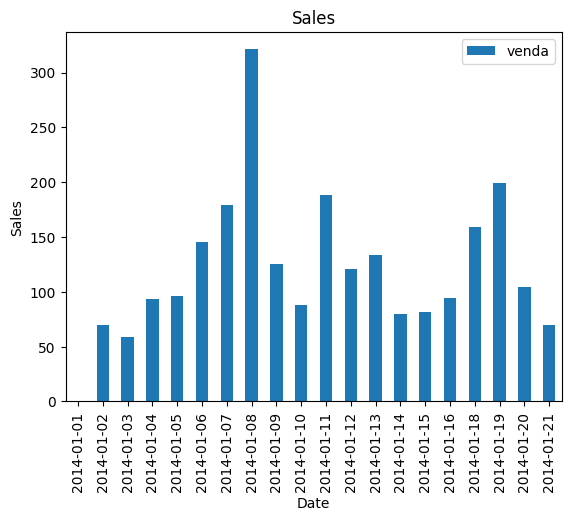

In [39]:
df.head(20).plot(x="data", y="venda", kind="bar")

plt.title("Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

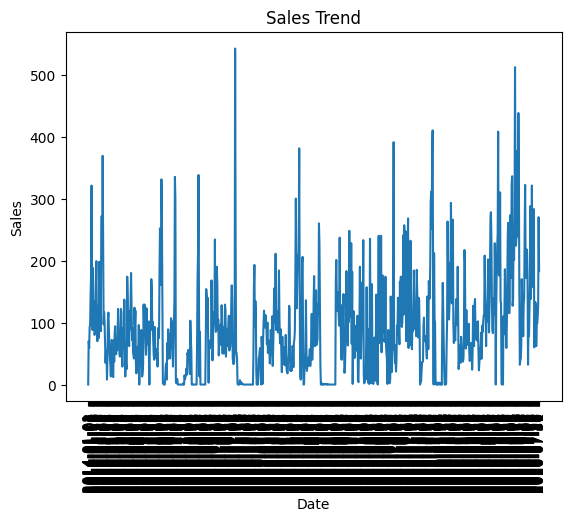

In [40]:
plt.plot(df["data"], df["venda"])

plt.title("Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.show()

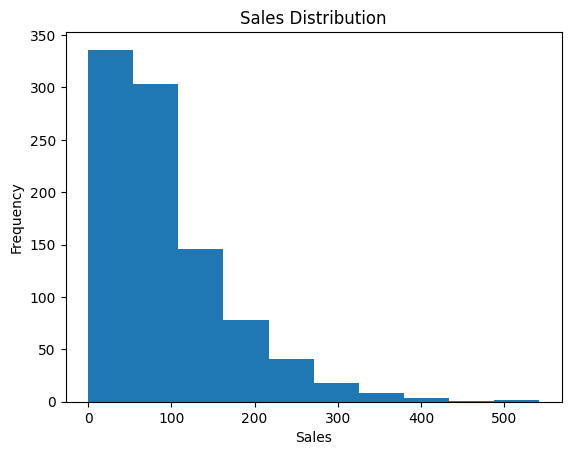

In [41]:
plt.hist(df["venda"])

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

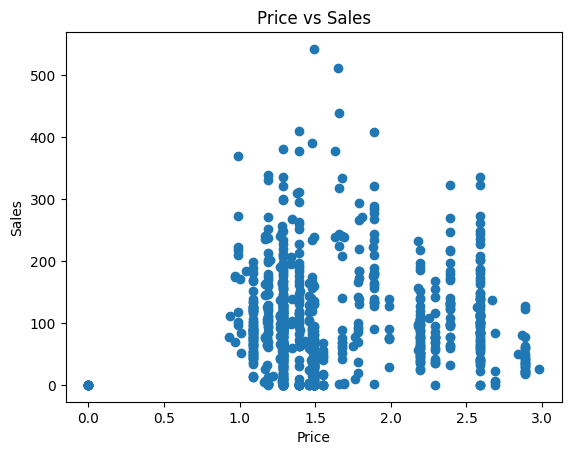

In [42]:
plt.scatter(df["preco"], df["venda"])

plt.title("Price vs Sales")
plt.xlabel("Price")
plt.ylabel("Sales")

plt.show()